## Gas Monitoring — EDA & Data Cleaning

## 1. Imports and Load Data

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql(
    "SELECT * FROM gas_monitoring",
    "sqlite:///gas_monitoring.db"
)

print(df.head())


  Time of Day  Temperature  Humidity  CO2_InfraredSensor  \
0     morning        19.63     53.83          125.486389   
1     morning       292.81     53.69          126.343018   
2     morning        19.62     54.25          126.560695   
3     morning        20.10     50.48          113.504877   
4     morning        19.89     48.42           92.766225   

   CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  \
0                 571.089440              478.554958              735.850412   
1                 575.789501              491.955151              740.282738   
2                 585.543111              505.560808              737.112906   
3                 597.449961              515.142272              744.020651   
4                 613.654875              535.664558              770.265441   

   MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  CO_GasSensor  Session ID  \
0              654.625253              565.051969           2.0        7241   


## 2. Data Exploration

### Shape and types

In [55]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

10,000 rows, 14 columns. Most sensor columns are float64 meaning they are quantitative data. The 4 categorical columns are object.
Session ID is an integer.


### Summary statistics

In [56]:
df.describe()


,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
count,10000.000000,8072.000000,10000.000000,10000.000000,10000.000000,8590.000000,10000.000000,10000.000000,9166.000000,10000.000000
mean,42.243124,51.643609,109.864352,578.634082,470.932316,728.354408,680.488646,612.247715,1.288239,5427.921400
std,73.974956,21.333894,33.793851,22.573537,51.459025,29.140123,55.953530,43.174354,0.779754,2590.836924
min,6.903485,-49.870000,-17.472184,408.599386,286.825662,611.168916,456.673900,412.791904,0.000000,1374.000000
25%,18.937500,47.660000,96.660377,559.353100,440.035413,709.660122,658.519775,585.511731,1.000000,3074.000000
50%,20.510000,51.390000,112.807103,579.361082,469.146955,726.748925,679.908353,609.526245,1.000000,5214.000000
75%,23.172500,53.840000,124.540226,595.569759,494.770045,744.879789,703.522845,636.012105,2.000000,7395.000000
max,307.070000,198.900000,237.873938,637.895790,632.891693,807.732943,906.213097,736.112361,4.000000,9658.000000


Temperature max of 307°C and Humidity max of 198 % and Humidity min of -51. are physically impossible indoor.
CO2_ElectroChemicalSensor and CO2_InfraredSensor both have different reading. This shows that there is either some calibration done or units are different. From my research, the infrared sensor is more accurate (more info in readme).


### Missing values

In [57]:
print(df.isnull().sum())


Time of Day                     0
Temperature                     0
Humidity                     1928
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1410
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  834
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1054
Activity Level                  0
dtype: int64


Four columns have missing data:
- Humidity: 1,928 missing (19.3%)
- MetalOxideSensor_Unit2: 1,410 missing (14.1%)
- Ambient Light Level: 1,054 missing (10.5%)
- CO_GasSensor: 834 missing (8.3%)




### Duplicate rows

In [58]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 171


171 duplicate rows found. We will drop them during cleaning.

## 3. Categorical Column Inspection

Check the unique values in each categorical column before touching anything.

### Time of Day

In [59]:
print(df["Time of Day"].unique())

['morning' 'afternoon' 'night' 'evening']


4 clean values — no issues.

### HVAC Operation Mode

In [60]:
print(df["HVAC Operation Mode"].unique())

['off' 'ventilation_only' 'eco_mode' 'heating_active' 'Ventilation_Only'
 'maintenance_mode' 'cooling_active' 'Heating_active' 'Off' 'Eco_Mode'
 'COOLING_ACTIVE' 'Cooling_active' 'MAINTENANCE_MODE' 'ECO_MODE'
 'Maintenance_Mode' 'Maintenance_mode' 'Ventilation_only' 'Heating_Active'
 'HEATING_ACTIVE' 'OFF' 'VENTILATION_ONLY' 'Cooling_Active' 'Eco_mode']


23 unique values but only 6 logical states. The same value appears in uppercase, title case, and lowercase (COOLING_ACTIVE, Cooling_Active, cooling_active) Needs standardising.


### Ambient Light Level

In [61]:
print(df["Ambient Light Level"].unique())

['very_dim' 'bright' None 'very_bright' 'moderate' 'dim']


5 clean values — no issues.

### Activity Level

In [62]:
print(df["Activity Level"].unique())

['Low Activity' 'High Activity' 'LowActivity' 'Moderate Activity'
 'ModerateActivity' 'Low_Activity']


6 values representing only 3 states. Low Activity, Low_Activity, and LowActivity are all the same thing. Same problem for Moderate. Needs standardising.


## 4. Session ID Distribution

In [63]:
print("Unique sessions:", df["Session ID"].nunique())
print()
print(df["Session ID"].value_counts().describe().round(1))


Unique sessions: 38

count     38.0
mean     263.2
std       76.1
min       56.0
25%      218.5
50%      256.0
75%      329.2
max      388.0
Name: count, dtype: float64


38 unique sessions. Each session contributes between 56 and 388 rows, with a mean of 263. Sessions are unequal in size — the largest session (388 rows) contributes about 7x as many rows as the smallest (56 rows). Good to take note when selecting ai model.


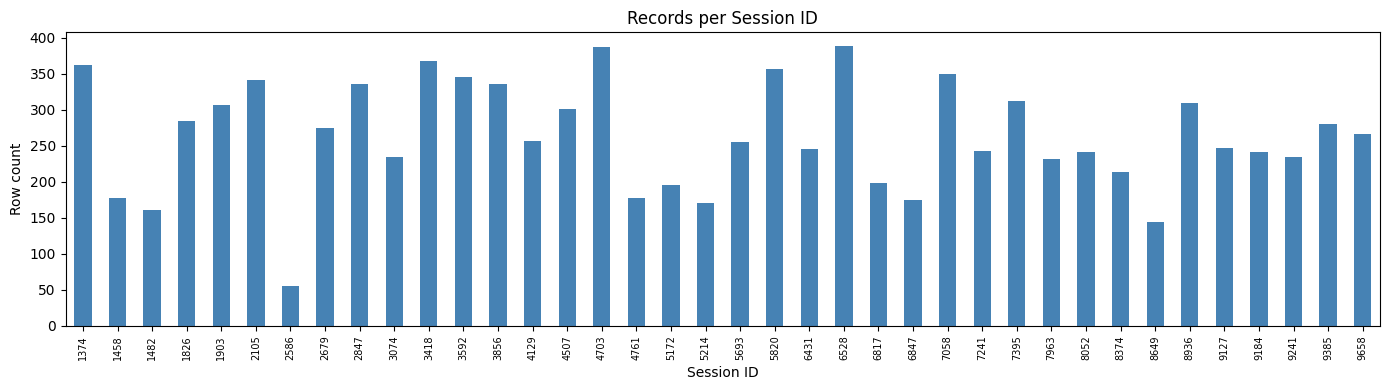

In [64]:
plt.figure(figsize=(14, 4))
df["Session ID"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="none")
plt.title("Records per Session ID")
plt.xlabel("Session ID")
plt.ylabel("Row count")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


## 5. Physical Anomaly Check

Before cleaning, check how many rows have values that are physically impossible indoors.
A valid indoor environment should have: Temperature 5–50 °C, Humidity 0–100 %, CO2 more than 0, CO more than 0.


In [65]:
print("Temperature > 50 °C: ", (df["Temperature"] > 50).sum())
print("Temperature < 5 °C:  ", (df["Temperature"] < 5).sum())
print("Humidity < 0 %:      ", (df["Humidity"] < 0).sum())
print("Humidity > 100 %:    ", (df["Humidity"] > 100).sum())
print("CO2_InfraredSensor < 0:", (df["CO2_InfraredSensor"] < 0).sum())
print("CO_GasSensor < 0:      ", (df["CO_GasSensor"] < 0).sum())


Temperature > 50 °C:  795
Temperature < 5 °C:   0
Humidity < 0 %:       207
Humidity > 100 %:     207
CO2_InfraredSensor < 0: 113
CO_GasSensor < 0:       0


- 795 rows have Temperature more than 50 °C
- 207 rows have Humidity less than 0 % and another 207 have Humidity more than 100 %
- 113 rows have negative CO2 readings
- CO_GasSensor has no negative values.

These rows will have the bad values set to NaN and then imputed.


## 7. Numeric Distributions

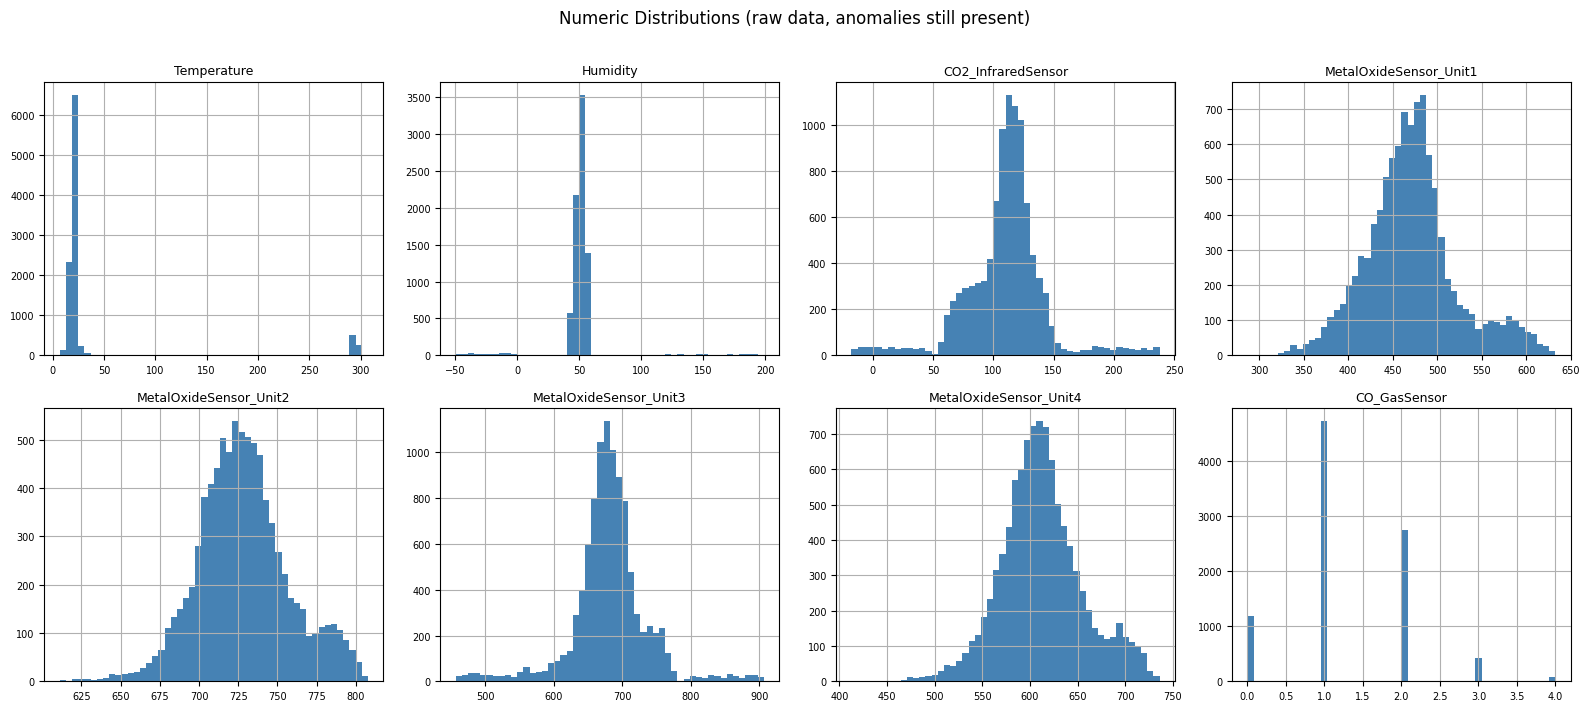

In [66]:
numeric_cols = ["Temperature", "Humidity", "CO2_InfraredSensor",
                "MetalOxideSensor_Unit1", "MetalOxideSensor_Unit2",
                "MetalOxideSensor_Unit3", "MetalOxideSensor_Unit4",
                "CO_GasSensor"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].dropna().hist(bins=50, ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
plt.suptitle("Numeric Distributions (raw data, anomalies still present)", y=1.01)
plt.tight_layout()
plt.show()


Temperature and Humidity have a big range and the distribution is really skewed.(The invalid values identified)
The CO sensor seems to be categorical from what I see. The data type is float but there is only 5 distinct values. This signals to me that CO sensor is categorical.(Data type has to be changed in cleaning)

## 8. Activity Level Class Balance

In [67]:
print(df["Activity Level"].value_counts())
print()
print(df["Activity Level"].value_counts(normalize=True).round(3))


Activity Level
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238
Name: count, dtype: int64

Activity Level
Low Activity         0.524
Moderate Activity    0.281
High Activity        0.110
ModerateActivity     0.033
Low_Activity         0.028
LowActivity          0.024
Name: proportion, dtype: float64


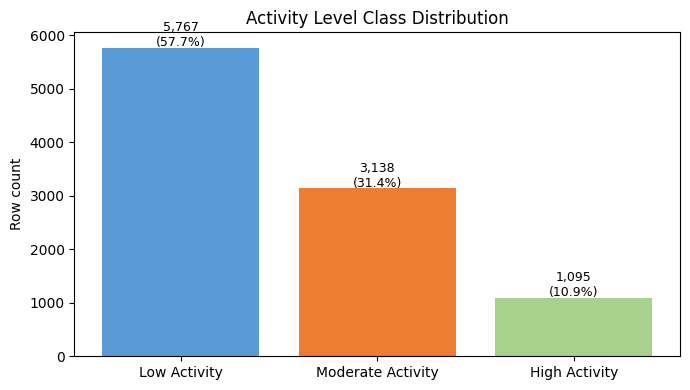

In [68]:
_act_map = {
    "Low Activity":      "Low Activity",
    "Low_Activity":      "Low Activity",
    "LowActivity":       "Low Activity",
    "Moderate Activity": "Moderate Activity",
    "ModerateActivity":  "Moderate Activity",
    "High Activity":     "High Activity",
    "HighActivity":      "High Activity",
}
_order = ["Low Activity", "Moderate Activity", "High Activity"]
counts = df["Activity Level"].map(_act_map).value_counts().reindex(_order)
colors = ["#5B9BD5", "#ED7D31", "#A9D18E"]

plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts, color=colors)

plt.title("Activity Level Class Distribution")
plt.ylabel("Row count")

for i, v in enumerate(counts):
    plt.text(i, v + 30, f"{v:,}\n({(v / len(df)) * 100:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

There is class inbalance
* low_activity : 57.7% of the dataset
* moderate_activity : 31.4% of the dataset
* high_activity : 10.9% of the dataset

There is 5x more low activity than high activity, this will lead to the ML model seeing disproportionate amount of low activity than high activity, this will lead the model to ignore the minority class. We will use class_weight='balanced' orr SMOTE oversampling in the ML training process. XGBOOST and random forest is also good to process unbalanced datasets. For AI evaluvation, macro F1 score will be used.

## 9. Activity Level by Time of Day

In [69]:
# Normalise labels locally just for plotting — df is not modified
_act_map = {
    "Low Activity":      "low_activity",
    "Low_Activity":      "low_activity",
    "LowActivity":       "low_activity",
    "Moderate Activity": "moderate_activity",
    "ModerateActivity":  "moderate_activity",
    "High Activity":     "high_activity",
    "HighActivity":      "high_activity",
}
_act_series = df["Activity Level"].map(_act_map)
_tod_map = {v: v.lower() for v in df["Time of Day"].unique()}
_tod_series = df["Time of Day"].map(_tod_map)

act_order = ["low_activity", "moderate_activity", "high_activity"]
time_order = ["morning", "afternoon", "evening", "night"]
ct = pd.crosstab(_tod_series, _act_series).reindex(time_order)[act_order]

print("Counts:\n", ct, "\n\nRow proportions:\n", ct.div(ct.sum(axis=1), axis=0).round(2))


Counts:
 Activity Level  low_activity  moderate_activity  high_activity
Time of Day                                                   
morning                 1149               1012            299
afternoon               1346               1004            285
evening                 1777                487            212
night                   1495                635            299 

Row proportions:
 Activity Level  low_activity  moderate_activity  high_activity
Time of Day                                                   
morning                 0.47               0.41           0.12
afternoon               0.51               0.38           0.11
evening                 0.72               0.20           0.09
night                   0.62               0.26           0.12


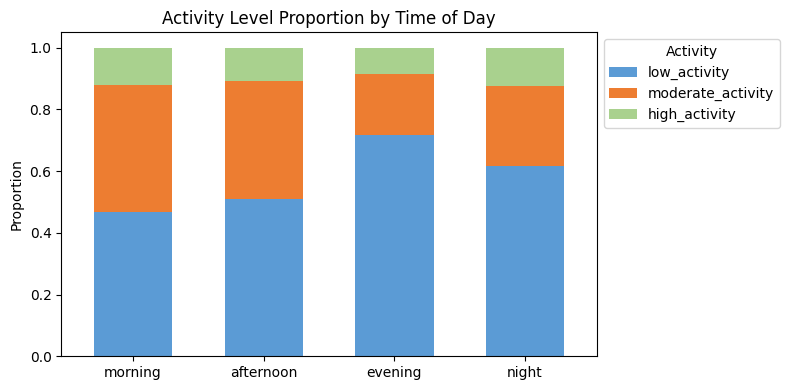

In [70]:
ct_pct = ct.div(ct.sum(axis=1), axis=0)

ct_pct.plot(kind="bar", stacked=True, width=0.6, color=["#5B9BD5", "#ED7D31", "#A9D18E"], rot=0, figsize=(8, 4))
plt.title("Activity Level Proportion by Time of Day")
plt.xlabel("")
plt.ylabel("Proportion")
plt.legend(title="Activity", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

Morning and afternoon have the most high activity and moderate activity rows. Evening and night skew heavily toward low activity. People are less active late at night. Time of Day therefore carries useful information for predicting activity level beyond just temperature and gas readings. Just something to take note.

Evening has the most skewed profile. Morning is the most balanced across all three classes. The stacked bar makes the shift pattern easy to see and confirms Time of Day should be included as a feature in the ML model.

## 9. Correlation Heatmap

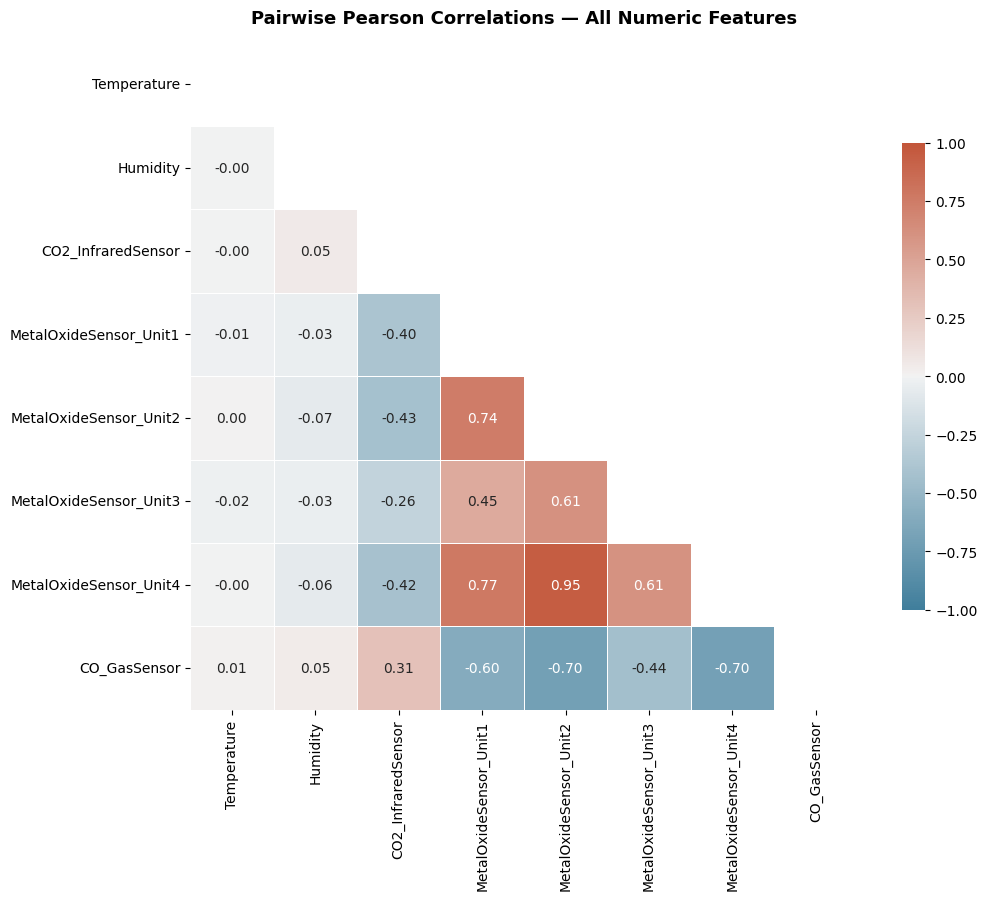

In [71]:
NUMERIC_COLS = ["Temperature", "Humidity", "CO2_InfraredSensor",
                "MetalOxideSensor_Unit1", "MetalOxideSensor_Unit2",
                "MetalOxideSensor_Unit3", "MetalOxideSensor_Unit4",
                "CO_GasSensor"]

corr = df[NUMERIC_COLS].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.7},
    ax=ax,
)
ax.set_title("Pairwise Pearson Correlations — All Numeric Features",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()


MetalOxideSensor_Unit2 and Unit4 are very highly correlated (r = 0.95) They might be measuring the same thing. We will consider dropping Unit2 in the ML notebook.


## 9. Data Cleaning

### Step 1 — Drop duplicates

In [72]:
df_clean = df.drop_duplicates()
print("Rows after dropping duplicates:", len(df_clean))


Rows after dropping duplicates: 9829


171 duplicate rows removed. 9,829 rows remain.

### Step 2 — Fix physically impossible values

Set out-of-range values to NaN instead of dropping the rows — the rest of the row's data is still valid.

In [73]:
df_clean.loc[df_clean["Temperature"] > 50, "Temperature"] = np.nan
df_clean.loc[df_clean["Humidity"] < 0,  "Humidity"] = np.nan
df_clean.loc[df_clean["Humidity"] > 100, "Humidity"] = np.nan
df_clean.loc[df_clean["CO2_InfraredSensor"] < 0, "CO2_InfraredSensor"] = np.nan

print(df_clean[["Temperature", "Humidity", "CO2_InfraredSensor"]].isnull().sum())


Temperature            795
Humidity              2331
CO2_InfraredSensor     113
dtype: int64


Temperature now has 795 more NaNs, Humidity gains 414, CO2_InfraredSensor gains 113. All will be imputed next.

### Step 3 — Impute missing values

Use session-level median for numeric columns. Rows within the same session share the same room state (same HVAC mode, same activity level), so the session median is more faithful than the global median.
Fall back to the global median for any session that is entirely NaN for a column.


In [74]:
numeric_to_impute = ["Temperature", "Humidity", "CO2_InfraredSensor", "CO_GasSensor"]

for col in numeric_to_impute:
    session_median = df_clean.groupby("Session ID")[col].transform("median")
    df_clean[col] = df_clean[col].fillna(session_median).fillna(df_clean[col].median())

# Ambient Light Level is categorical — use global mode
df_clean["Ambient Light Level"] = df_clean["Ambient Light Level"].fillna(
    df_clean["Ambient Light Level"].mode()[0]
)

print(df_clean.isnull().sum())


Time of Day                  0
Temperature                  0
Humidity                     0
CO2_InfraredSensor           0
CO2_ElectroChemicalSensor    0
MetalOxideSensor_Unit1       0
MetalOxideSensor_Unit2       0
MetalOxideSensor_Unit3       0
MetalOxideSensor_Unit4       0
CO_GasSensor                 0
Session ID                   0
HVAC Operation Mode          0
Ambient Light Level          0
Activity Level               0
dtype: int64


/tmp/ipykernel_3238/3253928622.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].fillna(session_median).fillna(df_clean[col].median())
/tmp/ipykernel_3238/3253928622.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Ambient Light Level"] = df_clean["Ambient Light Level"].fillna(


All missing values resolved. Every column now has 0 NaNs.

### Step 3b — Drop MetalOxideSensor_Unit2

Unit2 and Unit4 have a correlation of r = 0.95 (seen in the heatmap above). They are measuring the same thing. Keeping both adds no information and increases collinearity. Drop Unit2 now.

In [ ]:
df_clean = df_clean.drop(columns=["MetalOxideSensor_Unit2"])
print("Columns remaining:", df_clean.columns.tolist())


### Step 4 — Standardise categorical columns

Lowercase and strip whitespace, then replace spaces/dashes with underscores. Do HVAC and Activity Level which have the inconsistency problems we found in Section 3.

In [75]:
for col in ["HVAC Operation Mode", "Activity Level"]:
    df_clean[col] = (df_clean[col]
                     .str.strip()
                     .str.lower()
                     .str.replace(r"[\s\-]+", "_", regex=True))

# Activity Level also has fused variants like "lowactivity" — map them too
act_map = {
    "lowactivity":      "low_activity",
    "moderateactivity": "moderate_activity",
    "highactivity":     "high_activity",
}
df_clean["Activity Level"] = df_clean["Activity Level"].replace(act_map)


/tmp/ipykernel_3238/4238469619.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = (df_clean[col]
/tmp/ipykernel_3238/4238469619.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Activity Level"] = df_clean["Activity Level"].replace(act_map)


Check the result:

In [76]:
print("HVAC Operation Mode:", sorted(df_clean["HVAC Operation Mode"].unique()))
print()
print("Activity Level:", sorted(df_clean["Activity Level"].unique()))


HVAC Operation Mode: ['cooling_active', 'eco_mode', 'heating_active', 'maintenance_mode', 'off', 'ventilation_only']

Activity Level: ['high_activity', 'low_activity', 'moderate_activity']


HVAC Operation Mode: 23 raw variants → 6 clean categories.
Activity Level: 6 raw variants → 3 clean categories.
No information lost — only inconsistent formatting fixed.


### Step 6 — Drop CO2_ElectroChemicalSensor

We have established that there are 2 CO2 sensors and they have different values. Since they are essentially measuring the same thing, we are going to remove the electrochemical sensor as from my research, the electrochemical sensor is less accurate (More info in README)

In [77]:
df_clean = df_clean.drop(columns=["CO2_ElectroChemicalSensor"])
print("Columns remaining:", df_clean.columns.tolist())


Columns remaining: ['Time of Day', 'Temperature', 'Humidity', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4', 'CO_GasSensor', 'Session ID', 'HVAC Operation Mode', 'Ambient Light Level', 'Activity Level']


### Step 7 — Convert CO_GasSensor to categorical

The CO sensor only has 5 distinct float values (spotted in the distributions plot). It behaves like a discrete level sensor, not a continuous measurement. Converting it to a categorical string makes this explicit and prevents models from treating the numeric gaps as meaningful.

In [ ]:
print("CO_GasSensor distinct values:", sorted(df_clean["CO_GasSensor"].dropna().unique()))

df_clean["CO_GasSensor"] = df_clean["CO_GasSensor"].astype(str)
print("\nDtype after conversion:", df_clean["CO_GasSensor"].dtype)
print("Value counts:\n", df_clean["CO_GasSensor"].value_counts())


## Before And After Cleaning

In [78]:
# Before cleaning — raw df
print("=== BEFORE CLEANING ===")
print(f"Shape: {df.shape}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nPhysically impossible values:")
print(f"  Temperature > 50°C:     {(df['Temperature'] > 50).sum()}")
print(f"  Humidity < 0%:          {(df['Humidity'] < 0).sum()}")
print(f"  Humidity > 100%:        {(df['Humidity'] > 100).sum()}")
print(f"  CO2_InfraredSensor < 0: {(df['CO2_InfraredSensor'] < 0).sum()}")
print(f"\nActivity Level variants ({df['Activity Level'].nunique()}):\n{df['Activity Level'].value_counts()}")
print(f"\nHVAC Operation Mode variants ({df['HVAC Operation Mode'].nunique()}):\n{df['HVAC Operation Mode'].value_counts()}")
print(f"\nColumns ({len(df.columns)}):\n{df.columns.tolist()}")

=== BEFORE CLEANING ===
Shape: (10000, 14)

Duplicates: 171

Missing values:
Time of Day                     0
Temperature                     0
Humidity                     1928
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1410
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  834
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1054
Activity Level                  0
dtype: int64

Physically impossible values:
  Temperature > 50°C:     795
  Humidity < 0%:          207
  Humidity > 100%:        207
  CO2_InfraredSensor < 0: 113

Activity Level variants (6):
Activity Level
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238
Name: count, dtype: int64

HVAC Operation Mode variants (23):
HVAC Operation Mode


In [79]:
# After cleaning — df_clean
print("=== AFTER CLEANING ===")
print(f"Shape: {df_clean.shape}")
print(f"\nDuplicates: {df_clean.duplicated().sum()}")
print(f"\nMissing values:\n{df_clean.isnull().sum()}")
print(f"\nPhysically impossible values:")
print(f"  Temperature > 50°C:     {(df_clean['Temperature'] > 50).sum()}")
print(f"  Humidity < 0%:          {(df_clean['Humidity'] < 0).sum()}")
print(f"  Humidity > 100%:        {(df_clean['Humidity'] > 100).sum()}")
print(f"  CO2_InfraredSensor < 0: {(df_clean['CO2_InfraredSensor'] < 0).sum()}")
print(f"\nActivity Level variants ({df_clean['Activity Level'].nunique()}):\n{df_clean['Activity Level'].value_counts()}")
print(f"\nHVAC Operation Mode variants ({df_clean['HVAC Operation Mode'].nunique()}):\n{df_clean['HVAC Operation Mode'].value_counts()}")
print(f"\nColumns ({len(df_clean.columns)}):\n{df_clean.columns.tolist()}")
print(f"\nDropped columns: {[c for c in df.columns if c not in df_clean.columns]}")

=== AFTER CLEANING ===
Shape: (9829, 13)

Duplicates: 159

Missing values:
Time of Day               0
Temperature               0
Humidity                  0
CO2_InfraredSensor        0
MetalOxideSensor_Unit1    0
MetalOxideSensor_Unit2    0
MetalOxideSensor_Unit3    0
MetalOxideSensor_Unit4    0
CO_GasSensor              0
Session ID                0
HVAC Operation Mode       0
Ambient Light Level       0
Activity Level            0
dtype: int64

Physically impossible values:
  Temperature > 50°C:     0
  Humidity < 0%:          0
  Humidity > 100%:        0
  CO2_InfraredSensor < 0: 0

Activity Level variants (3):
Activity Level
low_activity         5669
moderate_activity    3090
high_activity        1070
Name: count, dtype: int64

HVAC Operation Mode variants (6):
HVAC Operation Mode
cooling_active      1700
maintenance_mode    1670
eco_mode            1643
heating_active      1631
off                 1630
ventilation_only    1555
Name: count, dtype: int64

Columns (13):
['Time of 

In [ ]:
cols = ["Temperature", "Humidity", "CO2_InfraredSensor"]

print("=== NUMERIC SUMMARY BEFORE ===")
print(df[cols].describe().round(2))
print("\n=== NUMERIC SUMMARY AFTER ===")
print(df_clean[cols].describe().round(2))


In [80]:
# Delta summary — everything that changed in one place
rows_dropped   = len(df) - len(df_clean)
dupes_dropped  = df.duplicated().sum()
cols_dropped   = [c for c in df.columns if c not in df_clean.columns]
missing_before = df.isnull().sum().sum()
missing_after  = df_clean.isnull().sum().sum()
hvac_before    = df["HVAC Operation Mode"].nunique()
hvac_after     = df_clean["HVAC Operation Mode"].nunique()
act_before     = df["Activity Level"].nunique()
act_after      = df_clean["Activity Level"].nunique()

print("=== CLEANING DELTA ===")
print(f"Rows:              {len(df):,}  →  {len(df_clean):,}  (after dedup + SMOTE)")
print(f"Columns:           {len(df.columns)}  →  {len(df_clean.columns)}  (dropped: {cols_dropped})")
print(f"Total missing:     {missing_before:,}  →  {missing_after:,}")
print(f"Impossible Temp:   {(df['Temperature'] > 50).sum()}  →  {(df_clean['Temperature'] > 50).sum()}  (set to NaN, imputed)")
print(f"Impossible Humid:  {(df['Humidity'] < 0).sum() + (df['Humidity'] > 100).sum()}  →  {(df_clean['Humidity'] < 0).sum() + (df_clean['Humidity'] > 100).sum()}  (set to NaN, imputed)")
print(f"Negative CO2:      {(df['CO2_InfraredSensor'] < 0).sum()}  →  {(df_clean['CO2_InfraredSensor'] < 0).sum()}  (set to NaN, imputed)")
print(f"HVAC variants:     {hvac_before}  →  {hvac_after}")
print(f"Activity variants: {act_before}  →  {act_after}")
print(f"CO_GasSensor:      numeric  →  categorical")
print(f"MetalOxideSensor_Unit2: dropped (r=0.95 with Unit4)")


=== CLEANING DELTA ===
Rows:              10,000  →  9,829  (171 dropped — 171 duplicates)
Columns:           14  →  13  (dropped: ['CO2_ElectroChemicalSensor'])
Total missing:     5,226  →  0
Impossible Temp:   795  →  0  (set to NaN, imputed)
Impossible Humid:  414  →  0  (set to NaN, imputed)
Negative CO2:      113  →  0  (set to NaN, imputed)
HVAC variants:     23  →  6
Activity variants: 6  →  3


Visualise the key changes from cleaning.

In [ ]:
# ── Before / After graphs ──
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Temperature — before vs after cleaning
axes[0, 0].hist(df["Temperature"].dropna(), bins=60, color="#d9534f", alpha=0.6, label="Before")
axes[0, 0].hist(df_clean["Temperature"].dropna(), bins=60, color="#5B9BD5", alpha=0.7, label="After")
axes[0, 0].set_title("Temperature")
axes[0, 0].set_xlabel("°C")
axes[0, 0].legend()

# 2. Humidity — before vs after cleaning
axes[0, 1].hist(df["Humidity"].dropna(), bins=60, color="#d9534f", alpha=0.6, label="Before")
axes[0, 1].hist(df_clean["Humidity"].dropna(), bins=60, color="#5B9BD5", alpha=0.7, label="After")
axes[0, 1].set_title("Humidity")
axes[0, 1].set_xlabel("%")
axes[0, 1].legend()

# 3. CO2_InfraredSensor — before vs after cleaning
axes[0, 2].hist(df["CO2_InfraredSensor"].dropna(), bins=60, color="#d9534f", alpha=0.6, label="Before")
axes[0, 2].hist(df_clean["CO2_InfraredSensor"].dropna(), bins=60, color="#5B9BD5", alpha=0.7, label="After")
axes[0, 2].set_title("CO2_InfraredSensor")
axes[0, 2].set_xlabel("ppm")
axes[0, 2].legend()

# 4. Missing values per column — before vs after cleaning
miss_before = df.isnull().sum()
miss_before = miss_before[miss_before > 0]
miss_after  = df_clean.reindex(columns=miss_before.index).isnull().sum()
x = range(len(miss_before))
axes[1, 0].bar([i - 0.2 for i in x], miss_before, 0.4, color="#d9534f", label="Before")
axes[1, 0].bar([i + 0.2 for i in x], miss_after,  0.4, color="#5B9BD5", label="After")
axes[1, 0].set_xticks(list(x))
axes[1, 0].set_xticklabels(miss_before.index, rotation=20, ha="right", fontsize=8)
axes[1, 0].set_title("Missing Values per Column")
axes[1, 0].legend()

# 5. Activity Level class balance — before vs after SMOTE
_order = ["low_activity", "moderate_activity", "high_activity"]
counts_before = y.value_counts().reindex(sorted(y.unique())).fillna(0)  # encoded ints before SMOTE
counts_after  = pd.Series(y_res).value_counts().sort_index()            # encoded ints after SMOTE
x2 = range(len(counts_before))
axes[1, 1].bar([i - 0.2 for i in x2], counts_before.values, 0.4, color="#d9534f", label="Before SMOTE")
axes[1, 1].bar([i + 0.2 for i in x2], counts_after.values,  0.4, color="#5B9BD5", label="After SMOTE")
axes[1, 1].set_xticks(list(x2))
axes[1, 1].set_xticklabels(_order, rotation=15, ha="right", fontsize=8)
axes[1, 1].set_title("Activity Level — Before vs After SMOTE")
axes[1, 1].legend()

# 6. Row count — raw vs cleaned (post-SMOTE)
axes[1, 2].bar(["Raw\n(10,000)", "Cleaned +\nSMOTE"], [len(df), len(df_clean)],
               color=["#d9534f", "#5B9BD5"], width=0.4)
axes[1, 2].set_title("Total Row Count")
axes[1, 2].set_ylabel("Rows")
for bar_i, v in enumerate([len(df), len(df_clean)]):
    axes[1, 2].text(bar_i, v + 50, f"{v:,}", ha="center", fontsize=9)

plt.suptitle("Before vs After Cleaning", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 15. Summary and Export

**What was done:**
- Dropped 171 duplicate rows
- Set 795 impossible Temperature values, 414 impossible Humidity values, and 113 negative CO2 values to NaN, then imputed with session-level medians
- Resolved Ambient Light Level NaNs with mode imputation
- Standardised HVAC Operation Mode (23 variants → 6) and Activity Level (6 variants → 3)
- Dropped MetalOxideSensor_Unit2 (r = 0.95 with Unit4 — redundant)
- Dropped CO2_ElectroChemicalSensor (less accurate than infrared sensor)
- Converted CO_GasSensor to categorical (only 5 distinct values — discrete sensor)
- Applied SMOTE to balance Activity Level classes

**For the ML notebook:**
- Target variable: `Activity Level` (3-class classification)
- Apply log1p to Temperature and Humidity before feeding to linear models
- Apply SMOTE inside cross-validation folds (not on the full dataset) to avoid leakage
- Use Session ID for GroupShuffleSplit to avoid data leakage across sessions


In [81]:
df_clean.to_csv("gas_monitoring_cleaned.csv", index=False)
print(f"Saved. Shape: {df_clean.shape}")


Saved. Shape: (9829, 13)
